<a href="https://colab.research.google.com/github/shrenikasharadkharade/python1/blob/main/Practical2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
data = pd.read_csv("/content/housing.csv")
data

,0.00632 18.00 2.310 0 0.5380 6.5750 65.20 4.0900 1 296.0 15.30 396.90 4.98 24.00
0,0.02731 0.00 7.070 0 0.4690 6.4210 78...
1,0.02729 0.00 7.070 0 0.4690 7.1850 61...
2,0.03237 0.00 2.180 0 0.4580 6.9980 45...
3,0.06905 0.00 2.180 0 0.4580 7.1470 54...
4,0.02985 0.00 2.180 0 0.4580 6.4300 58...
...,...
500,0.06263 0.00 11.930 0 0.5730 6.5930 69...
501,0.04527 0.00 11.930 0 0.5730 6.1200 76...
502,0.06076 0.00 11.930 0 0.5730 6.9760 91...
503,0.10959 0.00 11.930 0 0.5730 6.7940 89...


In [3]:
data.head()


,0.00632 18.00 2.310 0 0.5380 6.5750 65.20 4.0900 1 296.0 15.30 396.90 4.98 24.00
0,0.02731 0.00 7.070 0 0.4690 6.4210 78...
1,0.02729 0.00 7.070 0 0.4690 7.1850 61...
2,0.03237 0.00 2.180 0 0.4580 6.9980 45...
3,0.06905 0.00 2.180 0 0.4580 7.1470 54...
4,0.02985 0.00 2.180 0 0.4580 6.4300 58...


In [6]:
data.shape

(505, 1)

In [7]:
data.isnull()

,0.00632 18.00 2.310 0 0.5380 6.5750 65.20 4.0900 1 296.0 15.30 396.90 4.98 24.00
0,False
1,False
2,False
3,False
4,False
...,...
500,False
501,False
502,False
503,False


In [8]:
data.isnull().sum()

,0
0.00632 18.00 2.310 0 0.5380 6.5750 65.20 4.0900 1 296.0 15.30 396.90 4.98 24.00,0


In [9]:
data.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
500,False
501,False
502,False
503,False


In [11]:
data.columns

Index([' 0.00632  18.00   2.310  0  0.5380  6.5750  65.20  4.0900   1  296.0  15.30 396.90   4.98  24.00'], dtype='object')

In [12]:
data.empty

False

In [20]:
import pandas as pd

# The exact 14 column names you need to provide
RM = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE',
    'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'PRICE'
]

# Reload your dataset using whitespace separator and the names array
# Make sure to replace 'your_file_name.csv' with the actual name of your file!
data = pd.read_csv('housing.csv', sep=r'\s+', names=RM)

# Check the shape now
print(data.shape)  # This should now output: (506, 14)


(506, 14)


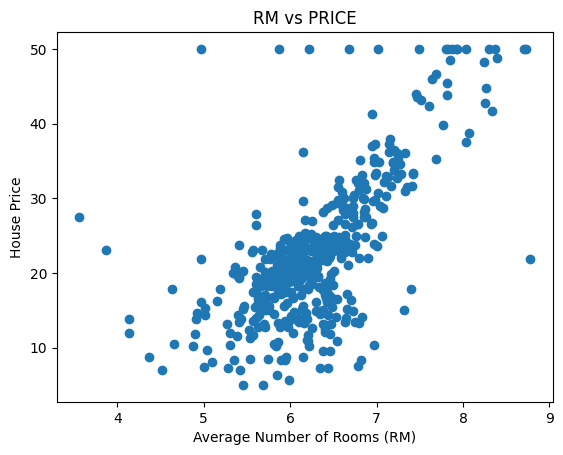

In [21]:
import matplotlib.pyplot as plt

plt.scatter(data["RM"], data["PRICE"])
plt.xlabel("Average Number of Rooms (RM)")
plt.ylabel("House Price")
plt.title("RM vs PRICE")
plt.show()


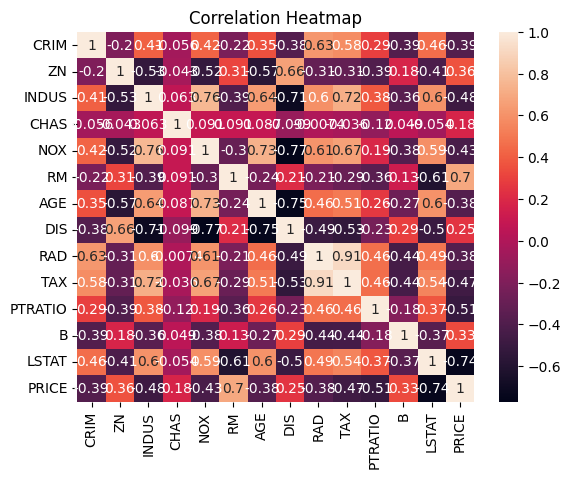

In [22]:
correlation = data.corr(numeric_only=True)
sns.heatmap(correlation, annot=True)
plt.title("Correlation Heatmap")
plt.show()


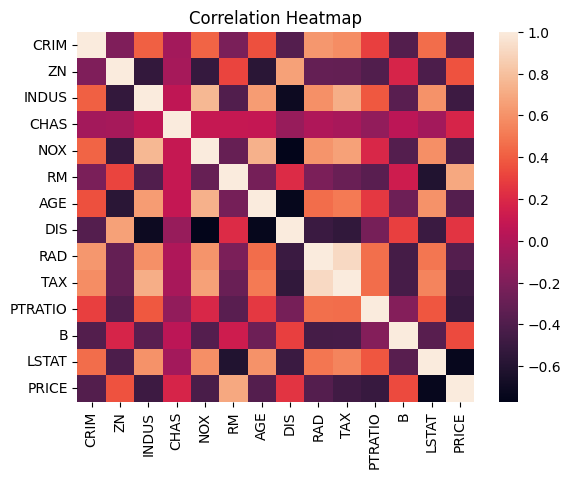

In [23]:
correlation = data.corr(numeric_only=True)
sns.heatmap(correlation, annot=False)
plt.title("Correlation Heatmap")
plt.show()


In [24]:
from sklearn.model_selection import train_test_split
#import features
X= data.drop("PRICE",axis=1)
#Target Variable
Y= data["PRICE"]
#Split dataset into training and testing data
X_train, X_test,Y_train, Y_test = train_test_split(X,Y,test_size=0.2, random_state=42)
print("Trainind data:",X_train.shape)
print("Testing data:",X_test.shape)

Trainind data: (404, 13)
Testing data: (102, 13)


In [25]:
print("Training Data:")
print(X_train.head())

Training Data:
         CRIM    ZN  INDUS  CHAS     NOX     RM   AGE     DIS  RAD    TAX  \
477  15.02340   0.0  18.10     0  0.6140  5.304  97.3  2.1007   24  666.0   
15    0.62739   0.0   8.14     0  0.5380  5.834  56.5  4.4986    4  307.0   
332   0.03466  35.0   6.06     0  0.4379  6.031  23.3  6.6407    1  304.0   
423   7.05042   0.0  18.10     0  0.6140  6.103  85.1  2.0218   24  666.0   
19    0.72580   0.0   8.14     0  0.5380  5.727  69.5  3.7965    4  307.0   

     PTRATIO       B  LSTAT  
477     20.2  349.48  24.91  
15      21.0  395.62   8.47  
332     16.9  362.25   7.83  
423     20.2    2.52  23.29  
19      21.0  390.95  11.28  


In [26]:
print("Testing Data:")
print(X_test.head())


Testing Data:
        CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
173  0.09178   0.0   4.05     0  0.510  6.416  84.1  2.6463    5  296.0   
274  0.05644  40.0   6.41     1  0.447  6.758  32.9  4.0776    4  254.0   
491  0.10574   0.0  27.74     0  0.609  5.983  98.8  1.8681    4  711.0   
72   0.09164   0.0  10.81     0  0.413  6.065   7.8  5.2873    4  305.0   
452  5.09017   0.0  18.10     0  0.713  6.297  91.8  2.3682   24  666.0   

     PTRATIO       B  LSTAT  
173     16.6  395.50   9.04  
274     17.6  396.90   3.53  
491     20.1  390.11  18.07  
72      19.2  390.91   5.52  
452     20.2  385.09  17.27  


In [27]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, Y_train)
print("Model Trained Successfully")


Model Trained Successfully


In [28]:
model.fit(X_train, Y_train)


LinearRegression()

In [29]:
model.predict(X_test)

array([28.99672362, 36.02556534, 14.81694405, 25.03197915, 18.76987992,
       23.25442929, 17.66253818, 14.34119   , 23.01320703, 20.63245597,
       24.90850512, 18.63883645, -6.08842184, 21.75834668, 19.23922576,
       26.19319733, 20.64773313,  5.79472718, 40.50033966, 17.61289074,
       27.24909479, 30.06625441, 11.34179277, 24.16077616, 17.86058499,
       15.83609765, 22.78148106, 14.57704449, 22.43626052, 19.19631835,
       22.43383455, 25.21979081, 25.93909562, 17.70162434, 16.76911711,
       16.95125411, 31.23340153, 20.13246729, 23.76579011, 24.6322925 ,
       13.94204955, 32.25576301, 42.67251161, 17.32745046, 27.27618614,
       16.99310991, 14.07009109, 25.90341861, 20.29485982, 29.95339638,
       21.28860173, 34.34451856, 16.04739105, 26.22562412, 39.53939798,
       22.57950697, 18.84531367, 32.72531661, 25.0673037 , 12.88628956,
       22.68221908, 30.48287757, 31.52626806, 15.90148607, 20.22094826,
       16.71089812, 20.52384893, 25.96356264, 30.61607978, 11.59

In [30]:
Y_Pred = model.predict(X_test)


In [31]:
print("Prediction Values:",Y_Pred[0:3])


Prediction Values: [28.99672362 36.02556534 14.81694405]


In [40]:
r2 = r2_score(Y_test, Y_Pred)
mae = mean_absolute_error(Y_test, Y_Pred)
mse = mean_squared_error(Y_test, Y_Pred)
rmse = np.sqrt(mse)

In [41]:
print("\n--- Model Evaluation Results ---")
print(f"R-squared (Accuracy) Score : {r2:.2f}")
print(f"Mean Absolute Error (MAE)   : ${mae * 1000:.2f}")
print(f"Mean Squared Error (MSE)    : {mse:.4f}")
print(f"Root Mean Squared Error(RMSE): ${rmse * 1000:.2f}")


--- Model Evaluation Results ---
R-squared (Accuracy) Score : 0.67
Mean Absolute Error (MAE)   : $3189.09
Mean Squared Error (MSE)    : 24.2911
Root Mean Squared Error(RMSE): $4928.60
